# Data Exploration and Preparation

This notebook helps you explore and prepare your dataset for training.


In [1]:
import torch
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import sys
import os

sys.path.append('..')

from src.data.dataset import ImageDataset


In [ ]:
from torchvision import datasets
dataset = datasets.CIFAR10(root='C:\AB_Personal\diffusion_101\CIFAR_10', download=True)

## 1. Load and Inspect Dataset


In [2]:
data_dir = 'C:\\AB_Personal\\diffusion_101\\CIFAR_10\\cifar-10-python\\cifar_10_images\\train'
os.listdir(data_dir)

['airplane',
 'automobile',
 'bird',
 'cat',
 'deer',
 'dog',
 'frog',
 'horse',
 'ship',
 'truck']

In [3]:
# Create dataset
# Replace with your data directory
data_dir = 'C:\\AB_Personal\\diffusion_101\\CIFAR_10\\cifar-10-python\\cifar_10_images'  # Update this path
raw_data_dir = '../data/raw/cifar10'
image_size = 64

# Check if data directory exists and has images
has_data = False
if os.path.exists(data_dir):  
    test, train = os.listdir(data_dir)
    folders_in_train = os.listdir(os.path.join(data_dir, train))  
    for folder in folders_in_train: 
        image_files = [f for f in os.listdir(os.path.join(data_dir, train, folder)) 
                    if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tiff'))]
    has_data = len(image_files) > 0
    print(len(image_files))

# Load dataset
if os.path.exists(data_dir):
    dataset = ImageDataset(os.path.join(data_dir,train), image_size=image_size)
    print(f"\nDataset size: {len(dataset)}")
    
    # Create dataloader
    dataloader = DataLoader(dataset, batch_size=16, shuffle=True, num_workers=0)
    
    # Get a batch
    batch = next(iter(dataloader))
    print(f"Batch shape: {batch.shape}")
    print(f"Value range: [{batch.min():.2f}, {batch.max():.2f}]")
    print(f"Expected range for normalized images: [-1, 1]")
else:
    print(f"Error: Could not create or access data directory {data_dir}")


5000
['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
50000

Dataset size: 50000
Batch shape: torch.Size([16, 3, 64, 64])
Value range: [-1.00, 1.00]
Expected range for normalized images: [-1, 1]


## 2. Visualize Sample Images


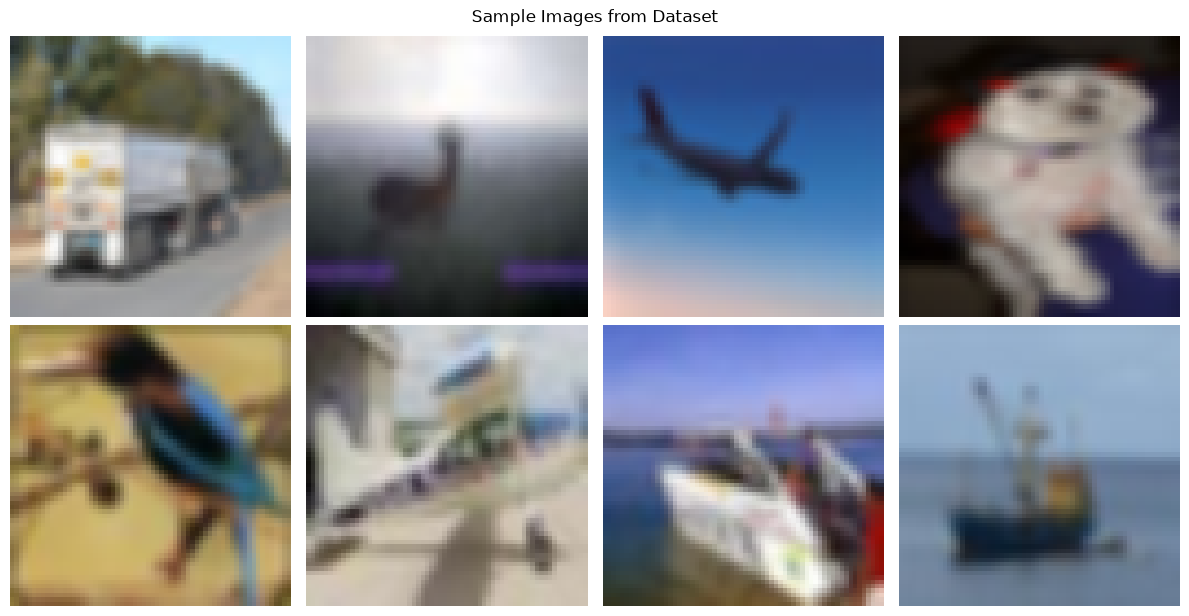

In [4]:
if 'batch' in locals():
    # Visualize batch
    fig, axes = plt.subplots(2, 4, figsize=(12, 6))
    
    for i, ax in enumerate(axes.flat):
        if i < batch.shape[0]:
            img = batch[i].permute(1, 2, 0)  # CHW -> HWC
            img = (img + 1) / 2  # Denormalize [-1,1] -> [0,1]
            img = torch.clamp(img, 0, 1)
            ax.imshow(img.numpy())
            ax.axis('off')
    
    plt.tight_layout()
    plt.suptitle('Sample Images from Dataset', y=1.02)
    plt.show()
else:
    print("No dataset loaded. Please run the previous cell first.")


## 3. Compute Dataset Statistics


In [5]:
def compute_stats(dataloader):
    """Compute mean and std of dataset."""
    mean = 0.0
    std = 0.0
    total = 0
    
    print("Computing statistics...")
    for images in dataloader:
        batch_samples = images.size(0)
        images = images.view(batch_samples, images.size(1), -1)
        mean += images.mean(2).sum(0)
        std += images.std(2).sum(0)
        total += batch_samples
    
    mean /= total
    std /= total
    return mean, std

if 'dataloader' in locals():
    mean, std = compute_stats(dataloader)
    print(f"\nMean per channel: {mean.numpy()}")
    print(f"Std per channel: {std.numpy()}")
    print(f"\nNote: Since images are normalized to [-1, 1],")
    print(f"mean should be close to 0 and std close to 1.")
else:
    print("No dataloader available. Please load dataset first.")


Computing statistics...

Mean per channel: [-0.01536703 -0.03385842 -0.10510535]
Std per channel: [0.38851887 0.38297656 0.38648215]

Note: Since images are normalized to [-1, 1],
mean should be close to 0 and std close to 1.


## 4. Check Image Distribution


In [ ]:
if 'batch' in locals():
    # Plot histogram of pixel values
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    
    for channel in range(3):
        channel_data = batch[:, channel, :, :].flatten().numpy()
        axes[channel].hist(channel_data, bins=50, alpha=0.7, edgecolor='black')
        axes[channel].set_title(f'Channel {channel} Distribution')
        axes[channel].set_xlabel('Pixel Value')
        axes[channel].set_ylabel('Frequency')
        axes[channel].axvline(0, color='red', linestyle='--', label='Zero')
        axes[channel].legend()
        axes[channel].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.suptitle('Pixel Value Distribution (Normalized to [-1, 1])', y=1.02)
    plt.show()
    
    print("For properly normalized images, the distribution should be")
    print("centered around 0 with values in the [-1, 1] range.")


## 5. Test Data Loading Speed


In [ ]:
import time

if 'dataloader' in locals():
    # Time data loading
    print("Testing data loading speed...")
    start = time.time()
    num_batches = 0
    for i, batch in enumerate(dataloader):
        if i >= 10:  # Test first 10 batches
            break
        num_batches += 1
    end = time.time()
    
    elapsed = end - start
    print(f"Time to load {num_batches} batches: {elapsed:.2f} seconds")
    print(f"Average time per batch: {elapsed / num_batches:.3f} seconds")
    print(f"Images per second: {num_batches * dataloader.batch_size / elapsed:.1f}")
    
    if elapsed / num_batches > 0.1:
        print("\n⚠ Warning: Data loading is slow. Consider:")
        print("  - Using more num_workers (if on Linux/Mac)")
        print("  - Using faster storage (SSD)")
        print("  - Reducing image size")
else:
    print("No dataloader available. Please load dataset first.")


## 6. Verify Data Preprocessing

Let's make sure images are properly preprocessed:


In [ ]:
if 'batch' in locals():
    # Check various properties
    print("Data Preprocessing Checklist:")
    print("=" * 40)
    
    # Check shape
    print(f"✓ Image shape: {batch.shape[1:]} (C, H, W)")
    assert batch.shape[1] == 3, "Expected 3 channels (RGB)"
    print("✓ 3 channels (RGB) confirmed")
    
    # Check value range
    min_val, max_val = batch.min().item(), batch.max().item()
    print(f"✓ Value range: [{min_val:.3f}, {max_val:.3f}]")
    if -1.1 <= min_val <= -0.9 and 0.9 <= max_val <= 1.1:
        print("✓ Values are in expected range [-1, 1]")
    else:
        print("⚠ Warning: Values outside expected range [-1, 1]")
    
    # Check if square
    h, w = batch.shape[2], batch.shape[3]
    if h == w:
        print(f"✓ Images are square ({h}x{w})")
    else:
        print(f"⚠ Images are not square ({h}x{w})")
    
    # Check dtype
    print(f"✓ Data type: {batch.dtype}")
    assert batch.dtype == torch.float32, "Expected float32"
    
    print("\n" + "=" * 40)
    print("Data is ready for training! ✓")


## 7. Optional: Use CIFAR-10 for Testing

If you don't have your own dataset yet, you can use CIFAR-10:


In [ ]:
# Uncomment to use CIFAR-10
# from torchvision import datasets
# import torchvision.transforms as transforms

# transform = transforms.Compose([
#     transforms.Resize((64, 64)),  # Resize to 64x64
#     transforms.ToTensor(),
#     transforms.Normalize([0.5], [0.5])  # Normalize to [-1, 1]
# ])

# cifar_dataset = datasets.CIFAR10(
#     root='./data', 
#     train=True, 
#     download=True, 
#     transform=transform
# )

# cifar_dataloader = DataLoader(
#     cifar_dataset, 
#     batch_size=32, 
#     shuffle=True,
#     num_workers=0
# )

# print(f"CIFAR-10 dataset size: {len(cifar_dataset)}")
# print(f"Number of classes: 10")

# # Visualize a batch
# batch_images, batch_labels = next(iter(cifar_dataloader))
# fig, axes = plt.subplots(2, 4, figsize=(12, 6))
# for i, ax in enumerate(axes.flat):
#     if i < batch_images.shape[0]:
#         img = batch_images[i].permute(1, 2, 0)
#         img = (img + 1) / 2
#         img = torch.clamp(img, 0, 1)
#         ax.imshow(img.numpy())
#         ax.axis('off')
# plt.tight_layout()
# plt.show()


## Tips for Data Preparation

1. **Image Size**: Start with 64x64 for faster training, then scale up
2. **Normalization**: Images should be normalized to [-1, 1] range
3. **Data Quality**: Remove corrupted or low-quality images
4. **Storage**: Use fast storage (SSD) for better data loading speed
5. **Augmentation**: Be careful with augmentations - they affect the learned distribution
6. **Consistency**: Ensure all images are RGB and same size
7. **Batch Size**: Adjust based on GPU memory (start with 16-32)

## Next Steps

Once your data is prepared and verified:
- Proceed to training with `scripts/train.py`
- Or explore the model architecture in the guides
